In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('laptop_price.csv', encoding='latin-1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [3]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

Text(0.5, 1.0, 'Distribution of Prices')

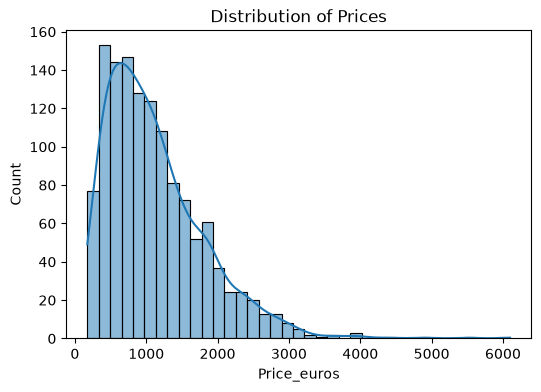

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price_euros'],kde=True)
plt.title('Distribution of Prices')

In [5]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

In [6]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

In [7]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

Text(0.5, 1.0, 'Prices Comparison with TypeName')

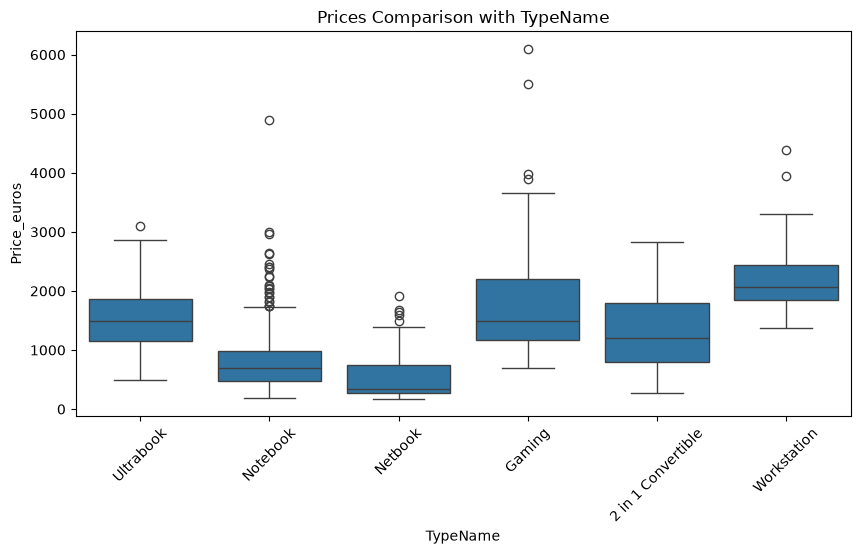

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='TypeName', y='Price_euros')
plt.xticks(rotation=45)
plt.title("Prices Comparison with TypeName")

In [9]:
df['Ram']=df['Ram'].str.replace('GB','').astype(int)
df['Weight']=df['Weight'].str.replace('kg','').astype(float)

In [10]:
df['Touchscreen']=df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [11]:
df['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

In [12]:
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

In [13]:
res=df['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
res

,0,1
0,2560,1600
1,1440,900
2,1920,1080
3,2880,1800
4,2560,1600
...,...,...
1298,1920,1080
1299,3200,1800
1300,1366,768
1301,1366,768


In [14]:
df['X_res']=res[0].astype(int)
df['Y_res']=res[1].astype(int)

In [15]:
df['PPI']=(((df['X_res']**2)+(df['Y_res']**2))**0.5/df['Inches']).astype(int)

In [16]:
df.drop(columns='ScreenResolution', inplace=True)

In [17]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz              190
Intel Core i7 7700HQ 2.8GHz             146
Intel Core i7 7500U 2.7GHz              134
Intel Core i7 8550U 1.8GHz               73
Intel Core i5 8250U 1.6GHz               72
                                       ... 
Intel Core i5 7200U 2.7GHz                1
Intel Pentium Dual Core 4405Y 1.5GHz      1
Intel Core M 6Y54 1.1GHz                  1
Samsung Cortex A72&A53 2.0GHz             1
AMD E-Series 9000 2.2GHz                  1
Name: count, Length: 118, dtype: int64

In [18]:
df['CPU_brand']=df['Cpu'].apply(lambda x: ' '.join(x.split()[0:3]) if x.split()[0]=='Intel' and 'Core' in x else ('Other Intel' if x.split()[0]=='Intel' in x else 'AMD'))

In [19]:
df['Cpu_speed_GHz']=df['Cpu'].str.extract(r'(\d+\.\d+)GHz').astype(float)

In [20]:
df=df.drop('Cpu',axis=1)

In [21]:
df['Memory']=df['Memory'].str.replace('GB','').str.replace('TB','000')

In [22]:
def extract_mem(mem_str,kind):
    parts=mem_str.split('+')
    for part in parts:
        total=0
        if kind in part:
            total+=int(''.join(filter(str.isdigit,part)))
        return total
df['SSD']=df['Memory'].apply(lambda x: extract_mem(x,'SSD'))
df['HDD']=df['Memory'].apply(lambda x: extract_mem(x,'HDD'))
            

In [23]:
df.drop(columns='Memory',inplace=True)

In [24]:
df['Gpu_brand']=df['Gpu'].apply(lambda x: x.split()[0])

In [25]:
df.drop(columns='Gpu',inplace=True)

In [26]:
df.drop(columns='Product',inplace=True)

In [27]:
df['Cpu_speed_GHz'] = df['Cpu_speed_GHz'].fillna(
    df['Cpu_speed_GHz'].median()
)

In [28]:
df_encoded=pd.get_dummies(df, columns=['Company', 'TypeName','OpSys','CPU_brand','Gpu_brand'], drop_first=True)

In [29]:
df_encoded=df_encoded.astype({col:int for col in df_encoded.select_dtypes('bool').columns})

Text(0.5, 1.0, 'Correlation of Output with Input')

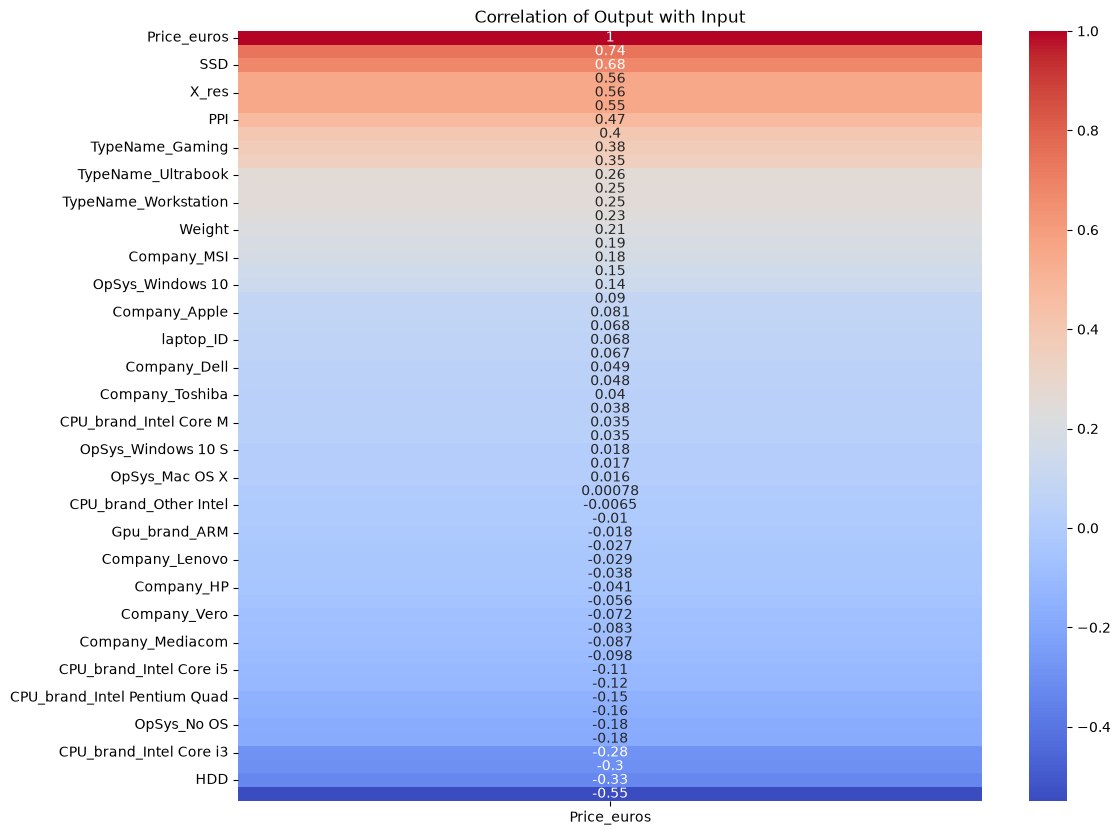

In [30]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(numeric_only=True)[['Price_euros']].sort_values(by='Price_euros', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation of Output with Input')

In [31]:
corr_series = df_encoded.corr(numeric_only=True)['Price_euros'].sort_values(ascending=False)
print(corr_series.to_string())

Price_euros                     1.000000
Ram                             0.743007
SSD                             0.676202
CPU_brand_Intel Core i7         0.556782
X_res                           0.556529
Y_res                           0.552809
PPI                             0.473264
Cpu_speed_GHz                   0.396029
TypeName_Gaming                 0.375789
Gpu_brand_Nvidia                0.348797
TypeName_Ultrabook              0.255658
IPS                             0.252208
TypeName_Workstation            0.249752
Company_Razer                   0.233756
Weight                          0.210370
Touchscreen                     0.191226
Company_MSI                     0.180100
OpSys_Windows 7                 0.152381
OpSys_Windows 10                0.137048
OpSys_macOS                     0.089928
Company_Apple                   0.080688
Inches                          0.068197
laptop_ID                       0.067830
Company_LG                      0.067053
Company_Dell    

In [32]:
cols_to_drop = [
    # A. Unnecessary ID Column
    'laptop_ID',
    
    # B. Multicollinear / Redundant Features (Signal captured in PPI)
    'X_res', 
    'Y_res', 
    'Inches',
    
    # C. Low/Near-Zero Correlation Noise (-0.05 to +0.05 range)
    'Company_Asus', 
    'Company_Lenovo', 
    'Company_HP', 
    'Company_Dell', 
    'Company_Toshiba', 
    'Company_Google', 
    'Company_Microsoft', 
    'Company_Samsung', 
    'Company_Huawei', 
    'Company_Xiaomi', 
    'Company_Fujitsu',
    'Company_LG',
    'CPU_brand_Intel Core M',
    'CPU_brand_Other Intel',
    'OpSys_Mac OS X',
    'OpSys_Windows 10 S',
    'Gpu_brand_ARM'
]

df_selected=df_encoded.drop(columns=[col for col in cols_to_drop if col in df_encoded.columns])

In [33]:
df_selected.head()

,Ram,Weight,Price_euros,Touchscreen,IPS,PPI,Cpu_speed_GHz,SSD,HDD,Company_Apple,...,OpSys_macOS,CPU_brand_Intel Celeron Dual,CPU_brand_Intel Celeron Quad,CPU_brand_Intel Core i3,CPU_brand_Intel Core i5,CPU_brand_Intel Core i7,CPU_brand_Intel Pentium Dual,CPU_brand_Intel Pentium Quad,Gpu_brand_Intel,Gpu_brand_Nvidia
0,8,1.37,1339.69,0,1,226,2.3,128,0,1,...,1,0,0,0,1,0,0,0,1,0
1,8,1.34,898.94,0,0,127,1.8,0,0,1,...,1,0,0,0,1,0,0,0,1,0
2,8,1.86,575.00,0,0,141,2.5,256,0,0,...,0,0,0,0,1,0,0,0,1,0
3,16,1.83,2537.45,0,1,220,2.7,512,0,1,...,1,0,0,0,0,1,0,0,0,0
4,8,1.37,1803.60,0,1,226,3.1,256,0,1,...,1,0,0,0,1,0,0,0,1,0


In [34]:
X=df_selected.drop(columns=['Price_euros'])
y=df['Price_euros']

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
numeric_cols = ['Ram', 'Weight',  'PPI', 'Cpu_speed_GHz', 'SSD', 'HDD'] 
scaler=StandardScaler()
X_train[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scaler.transform(X_test[numeric_cols])

In [38]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [39]:
models={ 'Linear Regression' : LinearRegression(), 'Lasso Model': Lasso(alpha=0.001), 'Ridge model': Ridge(alpha=1.0), 'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42), 'Decision Tree': DecisionTreeRegressor(random_state=42) } 
results=[]
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Name': name,
        'R2 score': round(r2, 4),
        'Mean Absolute Error (Euros)': round(mae, 2)
    })

print(results)

result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by='R2 score', ascending=False)

result_df

[{'Name': 'Linear Regression', 'R2 score': 0.7737, 'Mean Absolute Error (Euros)': 237.23}, {'Name': 'Lasso Model', 'R2 score': 0.7737, 'Mean Absolute Error (Euros)': 237.22}, {'Name': 'Ridge model', 'R2 score': 0.7701, 'Mean Absolute Error (Euros)': 237.53}, {'Name': 'Random Forest', 'R2 score': 0.8331, 'Mean Absolute Error (Euros)': 184.7}, {'Name': 'Decision Tree', 'R2 score': 0.7374, 'Mean Absolute Error (Euros)': 232.72}]


,Name,R2 score,Mean Absolute Error (Euros)
3,Random Forest,0.8331,184.70
0,Linear Regression,0.7737,237.23
1,Lasso Model,0.7737,237.22
2,Ridge model,0.7701,237.53
4,Decision Tree,0.7374,232.72


In [46]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators':[100,200,300],
    'max_depth':[None, 10,20,30],
    'min_samples_split':[2,5,10]
}

grid=GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2',n_jobs=-1)
grid.fit(X_train,y_train)
print('Best Params', grid.best_params_)
best_model = grid.best_estimator_ 

Best Params {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [47]:
y_pred = best_model.predict(X_test) 
final_r2 = r2_score(y_test, y_pred) 
final_mae = mean_absolute_error(y_test, y_pred)

In [50]:
final_r2

0.8344024575941349

In [51]:
import joblib

In [52]:
joblib.dump(best_model, 'laptop_price_model.pkl')
joblib.dump(scaler , 'Laptop_scaler.pkl')
joblib.dump(numeric_cols,'Laptop_num_Columns.pkl')
joblib.dump(X.columns.tolist(), 'laptop_columns.pkl')

['laptop_columns.pkl']